<a href="https://colab.research.google.com/github/kmunyaradzi/Pre-Trained-Model-Analysis/blob/main/train_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#

Mounted at /content/drive


In [ ]:
# Cell 2: Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [ ]:
# Cell 3: Creating 70/15/15 split from original dataset
import os
import shutil
import random
from sklearn.model_selection import train_test_split

print("=" * 60)
print("CREATING 70/15/15 DATASET SPLIT")
print("=" * 60)

# dataset path
original_path = '/content/drive/My Drive/pneumonia_detection/data/chest_xray'

# New path for organized splits
new_base_path = '/content/pneumonia_splits'

# Cleaning up previous split if it exists
if os.path.exists(new_base_path):
    shutil.rmtree(new_base_path)

# Creating new directory structure
for split in ['train', 'val', 'test']:
    for category in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(new_base_path, split, category), exist_ok=True)

# Get all images paths from train folder
normal_images = []
pneumonia_images = []

normal_path = os.path.join(original_path, 'train', 'NORMAL')
pneumonia_path = os.path.join(original_path, 'train', 'PNEUMONIA')

if os.path.exists(normal_path):
    normal_images = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
if os.path.exists(pneumonia_path):
    pneumonia_images = [os.path.join(pneumonia_path, f) for f in os.listdir(pneumonia_path) if f.endswith(('.jpeg', '.jpg', '.png'))]

print(f"Found {len(normal_images)} NORMAL images")
print(f"Found {len(pneumonia_images)} PNEUMONIA images")

# Splitting NORMAL images: 70% train, 15% val, 15% test
normal_train, normal_temp = train_test_split(normal_images, test_size=0.3, random_state=42)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=42)

# Spliting PNEUMONIA images: 70% train, 15% val, 15% test
pneumonia_train, pneumonia_temp = train_test_split(pneumonia_images, test_size=0.3, random_state=42)
pneumonia_val, pneumonia_test = train_test_split(pneumonia_temp, test_size=0.5, random_state=42)

# Copying files to new directories
def copy_files(file_list, destination_folder):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        dest_path = os.path.join(destination_folder, filename)
        shutil.copy2(file_path, dest_path)

# Copying NORMAL files
copy_files(normal_train, os.path.join(new_base_path, 'train', 'NORMAL'))
copy_files(normal_val, os.path.join(new_base_path, 'val', 'NORMAL'))
copy_files(normal_test, os.path.join(new_base_path, 'test', 'NORMAL'))

# Copying PNEUMONIA files
copy_files(pneumonia_train, os.path.join(new_base_path, 'train', 'PNEUMONIA'))
copy_files(pneumonia_val, os.path.join(new_base_path, 'val', 'PNEUMONIA'))
copy_files(pneumonia_test, os.path.join(new_base_path, 'test', 'PNEUMONIA'))

print("\n" + "=" * 60)
print("SPLIT COMPLETE")
print("=" * 60)
print(f"Training set:   {len(normal_train) + len(pneumonia_train)} images")
print(f"  NORMAL: {len(normal_train)}, PNEUMONIA: {len(pneumonia_train)}")
print(f"Validation set: {len(normal_val) + len(pneumonia_val)} images")
print(f"  NORMAL: {len(normal_val)}, PNEUMONIA: {len(pneumonia_val)}")
print(f"Test set:       {len(normal_test) + len(pneumonia_test)} images")
print(f"  NORMAL: {len(normal_test)}, PNEUMONIA: {len(pneumonia_test)}")

# Updating dataset path to new split
DATASET_PATH = new_base_path
print(f"\nNew dataset path: {DATASET_PATH}")

CREATING 70/15/15 DATASET SPLIT
Found 1342 NORMAL images
Found 3877 PNEUMONIA images

SPLIT COMPLETE
Training set:   3652 images
  NORMAL: 939, PNEUMONIA: 2713
Validation set: 783 images
  NORMAL: 201, PNEUMONIA: 582
Test set:       784 images
  NORMAL: 202, PNEUMONIA: 582

New dataset path: /content/pneumonia_splits


In [ ]:
# Cell 4: Setting dataset path
DATASET_PATH = '/content/pneumonia_splits'

import os
if os.path.exists(DATASET_PATH):
    print(f"Dataset path exists: {DATASET_PATH}")
    print(f"Train folder exists: {os.path.exists(os.path.join(DATASET_PATH, 'train'))}")
    print(f"Val folder exists: {os.path.exists(os.path.join(DATASET_PATH, 'val'))}")
    print(f"Test folder exists: {os.path.exists(os.path.join(DATASET_PATH, 'test'))}")
else:
    print(f"ERROR: {DATASET_PATH} not found. Run Cell 3 first.")

Dataset path exists: /content/pneumonia_splits
Train folder exists: True
Val folder exists: True
Test folder exists: True


In [ ]:
# Cell 5: Imports and Hyperparameters
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 15

print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Number of Epochs: {NUM_EPOCHS}")

Using device: cpu
Batch Size: 32
Learning Rate: 0.001
Number of Epochs: 15


In [ ]:
# Cell 6: Data Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined")

Transforms defined


In [ ]:
# Cell 7: Loading Datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'train'),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'val'),
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'test'),
    transform=val_transforms
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training set size: 3652
Validation set size: 783
Test set size: 784
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
# Cell 8: DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 115
Validation batches: 25
Test batches: 25


In [ ]:
# Cell 9: Building EfficientNet-B0 Model
print("Building EfficientNet-B0 model...")

model = models.efficientnet_b0(pretrained=True)

# Freezing early layers, train later layers
for name, param in model.named_parameters():
    if 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Replacing classifier head for binary classification
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1)
)

model = model.to(device)

# Computing class weights for imbalance
all_train_labels = []
for _, labels in train_loader:
    all_train_labels.extend(labels.numpy())

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=all_train_labels)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")
print("EfficientNet model ready!")

Building EfficientNet-B0 model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s]


Trainable parameters: 164,097
EfficientNet model ready!


In [ ]:
# Cell 10: Training Loop
import torch.optim.lr_scheduler as lr_scheduler

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0

scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # TRAINING
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % 30 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start

    print(f"\n  Epoch {epoch+1} Complete ({epoch_time:.1f}s):")
    print(f"    Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
    print(f"    Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # Learning rate adjustment
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"    Learning Rate adjusted: {old_lr:.6f} → {new_lr:.6f}")

    # Saving best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_efficientnet_model.pth')
        print(f"    *** Best model saved! (Val Acc: {best_val_acc:.4f}) ***")

    print("-" * 50)

print("\n" + "=" * 70)
print(f"TRAINING COMPLETE! Best Validation Accuracy: {best_val_acc:.4f}")


Starting training for 15 epochs...

--- Epoch 1/15 ---
  Batch 0/115 - Loss: 0.3570
  Batch 30/115 - Loss: 0.0981
  Batch 60/115 - Loss: 0.0691
  Batch 90/115 - Loss: 0.0839

  Epoch 1 Complete (565.0s):
    Train Loss: 0.1415, Train Acc: 0.8875
    Val Loss: 0.1449, Val Acc: 0.8212
    *** Best model saved! (Val Acc: 0.8212) ***
--------------------------------------------------

--- Epoch 2/15 ---
  Batch 0/115 - Loss: 0.1029
  Batch 30/115 - Loss: 0.1580
  Batch 60/115 - Loss: 0.0536
  Batch 90/115 - Loss: 0.1978

  Epoch 2 Complete (539.8s):
    Train Loss: 0.1145, Train Acc: 0.9042
    Val Loss: 0.1280, Val Acc: 0.8506
    *** Best model saved! (Val Acc: 0.8506) ***
--------------------------------------------------

--- Epoch 3/15 ---
  Batch 0/115 - Loss: 0.1348
  Batch 30/115 - Loss: 0.1369
  Batch 60/115 - Loss: 0.1108
  Batch 90/115 - Loss: 0.1055

  Epoch 3 Complete (544.2s):
    Train Loss: 0.1015, Train Acc: 0.9165
    Val Loss: 0.0788, Val Acc: 0.9183
    *** Best model 

In [ ]:
# Cell 11: Saving Model to Google Drive
save_path = '/content/drive/My Drive/pneumonia_detection/models/'
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_path, 'efficientnet_best_model.pth'))
print(f"Best model saved to: {save_path}efficientnet_best_model.pth")

# Saving training history
import pickle
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
    'best_val_acc': best_val_acc
}
with open(os.path.join(save_path, 'efficientnet_training_history.pkl'), 'wb') as f:
    pickle.dump(history, f)
print("Training history saved")

Best model saved to: /content/drive/My Drive/pneumonia_detection/models/efficientnet_best_model.pth
Training history saved


In [ ]:
# Cell 12: Final Test Evaluation
print("\n" + "=" * 60)
print("FINAL TEST EVALUATION - EfficientNet")
print("=" * 60)

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        all_predictions.extend(predictions.flatten())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
cm = confusion_matrix(all_labels, all_predictions)

print("\n" + "=" * 50)
print("EFFICIENTNET FINAL TEST RESULTS")
print("=" * 50)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 NORMAL    PNEUMONIA")
print(f"Actual NORMAL    {cm[0,0]:<10} {cm[0,1]}")
print(f"       PNEUMONIA {cm[1,0]:<10} {cm[1,1]}")

print(f"\nDetailed Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=['NORMAL', 'PNEUMONIA']))

# Saving results
results_path = '/content/drive/My Drive/pneumonia_detection/results/'
os.makedirs(results_path, exist_ok=True)

with open(os.path.join(results_path, 'efficientnet_test_results.txt'), 'w') as f:
    f.write("EfficientNet Pneumonia Detection - Final Test Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Test Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-Score:  {f1:.4f}\n")
    f.write(f"\nConfusion Matrix:\n")
    f.write(f"  TN: {cm[0,0]}, FP: {cm[0,1]}\n")
    f.write(f"  FN: {cm[1,0]}, TP: {cm[1,1]}\n")

print(f"\nResults saved to: {results_path}efficientnet_test_results.txt")


FINAL TEST EVALUATION - EfficientNet

EFFICIENTNET FINAL TEST RESULTS

Accuracy:  0.9247 (92.47%)
Precision: 0.9962
Recall:    0.9021
F1-Score:  0.9468

Confusion Matrix:
                 Predicted
                 NORMAL    PNEUMONIA
Actual NORMAL    200        2
       PNEUMONIA 57         525

Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.78      0.99      0.87       202
   PNEUMONIA       1.00      0.90      0.95       582

    accuracy                           0.92       784
   macro avg       0.89      0.95      0.91       784
weighted avg       0.94      0.92      0.93       784


Results saved to: /content/drive/My Drive/pneumonia_detection/results/efficientnet_test_results.txt


Training curves saved


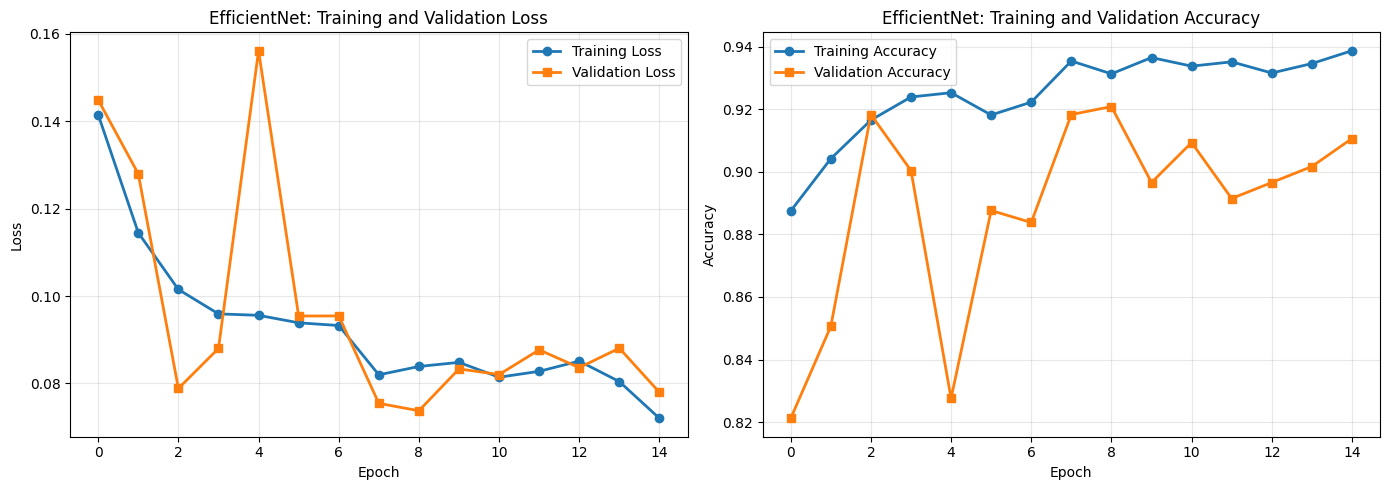

In [ ]:
# Cell 13: Plotting  Training Curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('EfficientNet: Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('EfficientNet: Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'efficientnet_training_curves.png'), dpi=300)
plt.savefig('efficientnet_training_curves.png', dpi=300)
print(f"Training curves saved")
plt.show()

Confusion matrix saved


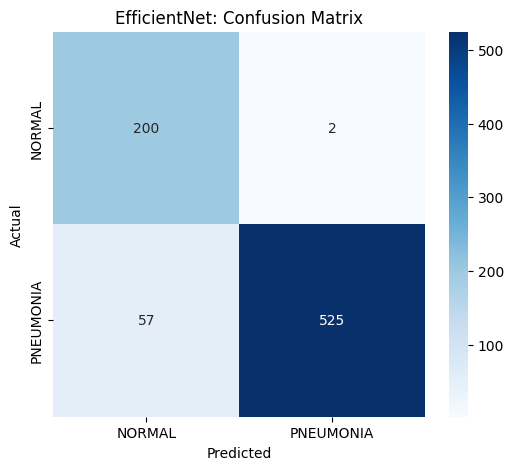

In [ ]:
# Cell 14: Plotting Confusion Matrix
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNet: Confusion Matrix')

plt.savefig(os.path.join(results_path, 'efficientnet_confusion_matrix.png'), dpi=300)
plt.savefig('efficientnet_confusion_matrix.png', dpi=300)
print(f"Confusion matrix saved")
plt.show()

In [ ]:
# Cell 15: Downloading results to local computer
from google.colab import files

files_to_download = [
    'best_efficientnet_model.pth',
    'efficientnet_training_curves.png',
    'efficientnet_confusion_matrix.png'
]

for file_name in files_to_download:
    try:
        files.download(file_name)
        print(f"Downloaded: {file_name}")
    except:
        print(f"Could not download: {file_name}")

print("\n✅ EfficientNet training complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_efficientnet_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: efficientnet_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: efficientnet_confusion_matrix.png

✅ EfficientNet training complete!
Best Validation Accuracy: 0.9208
Test Accuracy: 0.9247
